# Drone Rescue v2 - Enhanced Dueling Double-DQN (CUDA Enabled)

This notebook trains the Enhanced DQN Drone agent:
1. **Dueling Double-DQN Architecture**: 4-layer Deep CNN (\times9$ full receptive field) + separate Value & Advantage streams + Double DQN target estimation.
2. **CUDA Acceleration**: Automatically detects and leverages GPU acceleration if available.
3. **Curriculum Learning**: Progresses from smaller grids with fewer obstacles (\times6$, 10% obstacles $\rightarrow$ \times8$, 15% $\rightarrow$ \times10$, 20%).
4. **Discounted Potential-Based Reward Shaping**: (s, s') = d(s, \text{rescue}) - \gamma d(s', \text{rescue})$ preventing local minima wall oscillations.
5. **Comprehensive Visual Replay**: ASCII trajectories across unseen procedural test mazes.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from drone_rescue.training.train_dqn import TrainingConfig, train_dqn, evaluate_dqn
from drone_rescue.environment.grid_world import GridWorldEnv
from drone_rescue.environment.map_generator import generate_static_map
from drone_rescue.environment.observation import encode_observation
from drone_rescue.visualization.replay import render_grid, render_path


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device} | CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

smoke_config = TrainingConfig(episodes=10, evaluation_interval=5, evaluation_episodes=3, device=device)
agent, smoke_history = train_dqn(smoke_config)
print("Smoke test passed successfully!")


Using device: cuda | CUDA Available: True
Device Name: NVIDIA GeForce RTX 3050 Laptop GPU
Training on device: cuda (CUDA available: True)
episode 0005 | reward   -604.0 | success 0.00 | epsilon 0.994
episode 0010 | reward   -613.3 | success 0.00 | epsilon 0.985
Smoke test passed successfully!


## Full Training Run (Dueling Double DQN + Curriculum)

In [3]:
config = TrainingConfig(
    episodes=1000,
    size=10,
    obstacle_probability=0.2,
    seed=42,
    learning_rate=2.5e-4,
    shaping_scale=1.0,
    batch_size=64,
    exploration_start=1.0,
    exploration_end=0.08,
    exploration_duration=40_000,
    curriculum=True,
    device=device,
    evaluation_interval=40,
    evaluation_episodes=20,
)
agent, history = train_dqn(config)


Training on device: cuda (CUDA available: True)
episode 0040 | reward   -538.8 | success 0.00 | epsilon 0.942
episode 0080 | reward   -467.9 | success 0.10 | epsilon 0.893
episode 0120 | reward   -434.6 | success 0.05 | epsilon 0.860
episode 0160 | reward   -446.9 | success 0.10 | epsilon 0.820
episode 0200 | reward   -446.6 | success 0.10 | epsilon 0.791
episode 0240 | reward   -505.7 | success 0.15 | epsilon 0.752
episode 0280 | reward   -584.8 | success 0.00 | epsilon 0.684
episode 0320 | reward   -490.6 | success 0.00 | epsilon 0.619
episode 0360 | reward   -424.4 | success 0.10 | epsilon 0.559
episode 0400 | reward   -504.6 | success 0.05 | epsilon 0.502
episode 0440 | reward   -445.4 | success 0.10 | epsilon 0.443
episode 0480 | reward   -472.4 | success 0.10 | epsilon 0.380
episode 0520 | reward   -471.4 | success 0.10 | epsilon 0.309
episode 0560 | reward   -390.4 | success 0.15 | epsilon 0.218
episode 0600 | reward   -354.9 | success 0.10 | epsilon 0.131
episode 0640 | reward 

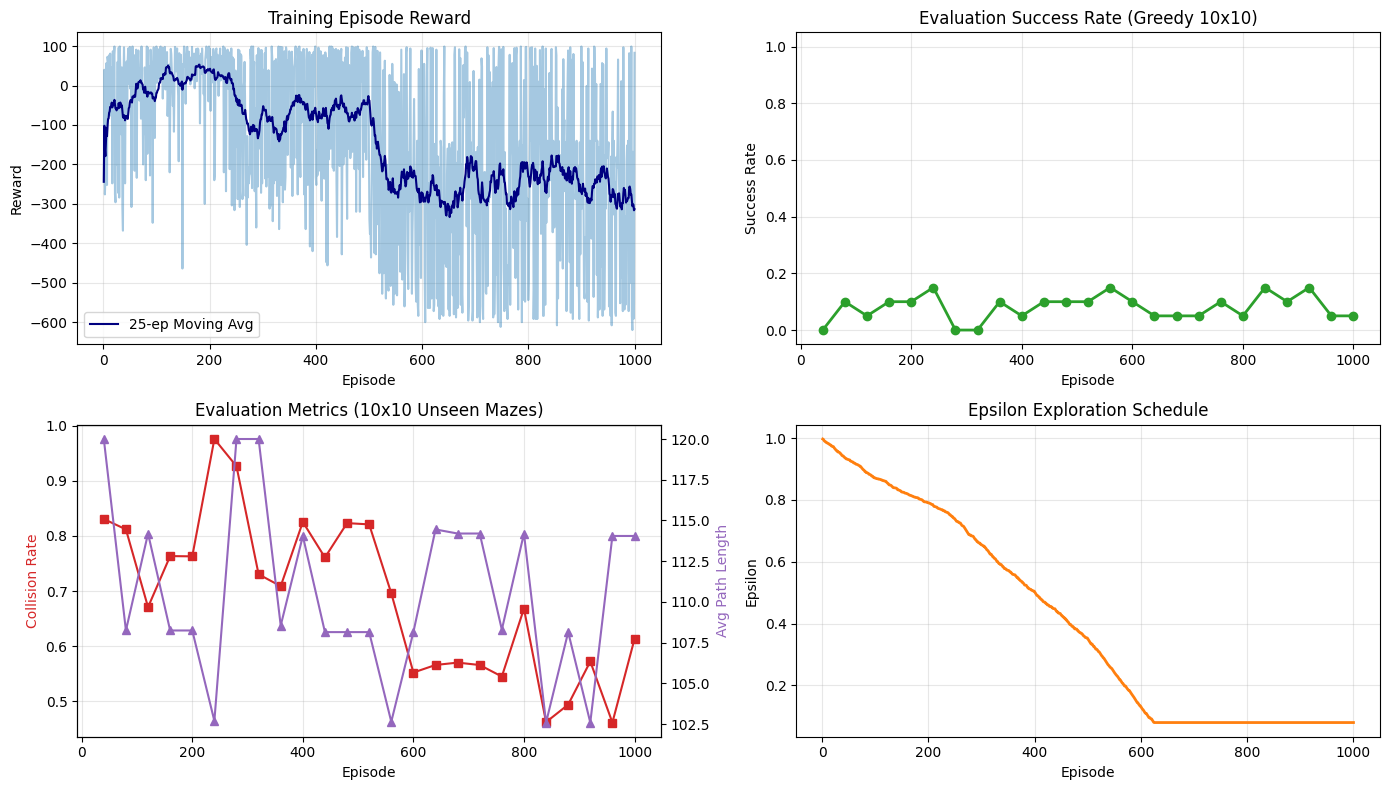

In [4]:
history_frame = pd.DataFrame(history)
evaluation_frame = history_frame.dropna(subset=["success_rate"]).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Episode Reward
axes[0, 0].plot(history_frame["episode"], history_frame["reward"], alpha=0.4, color="tab:blue")
axes[0, 0].plot(history_frame["episode"], history_frame["reward"].rolling(25, min_periods=1).mean(), color="navy", label="25-ep Moving Avg")
axes[0, 0].set_title("Training Episode Reward")
axes[0, 0].set_xlabel("Episode")
axes[0, 0].set_ylabel("Reward")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Evaluation Success Rate
axes[0, 1].plot(evaluation_frame["episode"], evaluation_frame["success_rate"], marker="o", color="tab:green", linewidth=2)
axes[0, 1].set_title("Evaluation Success Rate (Greedy 10x10)")
axes[0, 1].set_xlabel("Episode")
axes[0, 1].set_ylabel("Success Rate")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(True, alpha=0.3)

# 3. Collision Rate vs Path Length
ax_twin = axes[1, 0].twinx()
axes[1, 0].plot(evaluation_frame["episode"], evaluation_frame["collision_rate"], marker="s", color="tab:red", label="Collision Rate")
ax_twin.plot(evaluation_frame["episode"], evaluation_frame["average_path_length"], marker="^", color="tab:purple", label="Avg Path Length")
axes[1, 0].set_title("Evaluation Metrics (10x10 Unseen Mazes)")
axes[1, 0].set_xlabel("Episode")
axes[1, 0].set_ylabel("Collision Rate", color="tab:red")
ax_twin.set_ylabel("Avg Path Length", color="tab:purple")
axes[1, 0].grid(True, alpha=0.3)

# 4. Epsilon Exploration Decay
axes[1, 1].plot(history_frame["episode"], history_frame["epsilon"], color="tab:orange", linewidth=2)
axes[1, 1].set_title("Epsilon Exploration Schedule")
axes[1, 1].set_xlabel("Episode")
axes[1, 1].set_ylabel("Epsilon")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
output_dir = Path("results/dqn_v2")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "training_curves.png", dpi=120)
plt.show()


In [6]:
output_dir = Path("results/dqn_v2")
output_dir.mkdir(parents=True, exist_ok=True)

torch.save(agent.online_network.state_dict(), output_dir / "dqn_v2.pt")
history_frame.to_csv(output_dir / "training_history_v2.csv", index=False)
print("Saved model checkpoint and training history.")
print("Final Evaluation Checkpoints (10x10 Unseen Mazes) ---")
print(evaluation_frame[["episode", "average_reward", "success_rate", "average_path_length", "collision_rate"]].tail(10).to_string(index=False))


Saved model checkpoint and training history.
Final Evaluation Checkpoints (10x10 Unseen Mazes) ---
 episode  average_reward  success_rate  average_path_length  collision_rate
     640         -387.45          0.05               114.45        0.565749
     680         -388.60          0.05               114.20        0.570053
     720         -386.60          0.05               114.20        0.565674
     760         -352.30          0.10               108.30        0.544783
     800         -433.40          0.05               114.20        0.668126
     840         -294.20          0.15               102.60        0.461988
     880         -329.75          0.10               108.15        0.493759
     920         -339.40          0.15               102.60        0.572125
     960         -338.45          0.05               114.05        0.461201
    1000         -407.65          0.05               114.05        0.612889


## Visual Policy Replay on Unseen Test Mazes

In [ ]:
print("=== Visual Rollouts with Trained Dueling Double-DQN Agent ===")
test_seeds = [101, 202, 303, 404]

for seed in test_seeds:
    test_map = generate_static_map(size=10, obstacle_probability=0.2, seed=seed)
    env = GridWorldEnv(test_map.obstacles, test_map.start, test_map.rescue, max_steps=120)
    obs = encode_observation(env.reset().observation, size=10)
    
    path = [tuple(env.start)]
    done = False
    total_reward = 0.0
    
    while not done:
        action = agent.select_action(obs, greedy=True)
        result = env.step(action)
        obs = encode_observation(result.observation, size=10)
        path.append(tuple(env._drone))
        total_reward += result.reward
        done = result.terminated or result.truncated

    status = "SUCCESS" if result.info["success"] else ("COLLISION" if result.info["collision"] else "TIMEOUT")
    print(f"--- Test Map Seed {seed} | Status: {status} | Steps: {result.info['path_length']} | Reward: {total_reward:.1f} ---")
    print("Initial Grid (S = Start, R = Rescue, # = Obstacle, . = Free):")
    print(render_grid(test_map.obstacles, test_map.start, test_map.rescue))
    print("Executed Path Trajectory (* = Drone Path):")
    print(render_path(test_map.obstacles, path, test_map.start, test_map.rescue))


=== Visual Rollouts with Trained Dueling Double-DQN Agent ===
--- Test Map Seed 101 | Status: TIMEOUT | Steps: 120 | Reward: -140.0 ---
Initial Grid (S = Start, R = Rescue, # = Obstacle, . = Free):
+---------------------+
| . . . . . . . . . . |
| . . . X . . . . . . |
| . . X . . . . . . . |
| . . . . . . . . . . |
| . X . . X X . . X . |
| . . . . X R . X . X |
| . X X X . . . . . . |
| . . . . . . . . . . |
| S . . X . . X . X . |
| . . X . . . X X . . |
+---------------------+
Executed Path Trajectory (* = Drone Path):
+---------------------+
| . . . . . . . . . . |
| . . . X . . . . . . |
| . . X . . . . . . . |
| . . . . . . . . . . |
| . X . . X X . . X . |
| . . . . X R . X . X |
| . X X X . . . . . . |
| o . . . . . . . . . |
| S . . X . . X . X . |
| . . X . . . X X . . |
+---------------------+
--- Test Map Seed 202 | Status: TIMEOUT | Steps: 120 | Reward: -140.0 ---
Initial Grid (S = Start, R = Rescue, # = Obstacle, . = Free):
+---------------------+
| . . . X X . . . . . |

: 